In [3]:
import numpy as np 
from scipy.interpolate import interp1d
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import bezier
import os

In [4]:
class airfoil_structured:
    #класс для хранения данных о профиле с структурированными точками (расстояние между всеми абсциссами одинаковое)
    def __init__(self, r_forw, up_coords, down_coords, teta, dy_te, min_thick = -1):   
        self.N = len(up_coords) + 3
        self.r_forw = r_forw
        self.dy_te = dy_te
        self.x_coords = np.append([0], np.linspace(0, 1, self.N-1)) #вторая точка должна висеть на нуле и задавать 1) радиус кривизны 2) вертикальность касательной передней кромки 
        self.up_y_coords = np.concatenate(([0, 0], up_coords, [dy_te/2]))
        dx = self.x_coords[-1] - self.x_coords[-2]
        penultimate_y = np.tan(np.atan((self.up_y_coords[-2]-self.up_y_coords[-1])/dx)-teta) * dx #нижняя точка подвешивается углом задней кромки 
        self.down_y_coords = np.concatenate(([0, 0], down_coords, [penultimate_y-dy_te/2], [-dy_te/2]))
        D = self.x_coords[2] #там на самом деле сложная формула и с ней можно ознакомиться в папке с материалами, но она упрощается до такого вида
        t = (r_forw*D*(self.N-2)/(self.N-1))**0.5
        self.up_y_coords[1] = t
        self.down_y_coords[1] = -t
        self.update_curve()
        if min_thick != -1: self.correct_thick(min_thick)

    def update_curve(self): 
        """
        Создает объекты двух кривых Безье
        """
        upnodes = np.asfortranarray([self.x_coords, self.up_y_coords])
        downnodes = np.asfortranarray([self.x_coords, self.down_y_coords])
        self.upcurve = bezier.Curve.from_nodes(upnodes)
        self.downcurve = bezier.Curve.from_nodes(downnodes)
        
    def coords(self, Ncoords):
        t_space = np.linspace(0, 1, Ncoords)
        up_coords = self.upcurve.evaluate_multi(t_space)
        down_coords = self.downcurve.evaluate_multi(t_space)
        return up_coords, down_coords
    
    def self_intersect(self):
        if self.dy_te != 0: intersec_num = 1
        else: intersec_num = 2
        intersections = self.upcurve.intersect(self.downcurve)
        return len(intersections[0]) > intersec_num
    
    def plot(self, show_circle = False):
        data = self.coords(100)
        x_coords = np.append(data[0][0], data[1][0][::-1])
        y_coords = np.append(data[0][1], data[1][1][::-1])
        plt.figure(figsize=(9, 5))
        plt.plot(x_coords, y_coords, 'b-', linewidth=2)  
        plt.title(f"Профиль по {(self.N-3)*2+1} параметрам, толщина = {round(self.thick()[0], 2)}%", fontsize=14)
        plt.xlabel("X", fontsize=12)
        plt.ylabel("Y", fontsize=12)
        plt.grid()
        plt.axis('equal')  
        plt.scatter(self.x_coords, self.up_y_coords, color = "black", s=25)
        plt.scatter(self.x_coords, self.down_y_coords, color = "black", s=25)  
        if(show_circle):
            plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)  # Горизонтальная ось
            plt.gca().add_artist(plt.Circle((self.r_forw, 0), radius=self.r_forw, fill = False))
        plt.show()
        
    def create_selig_file(self, N):
        upper_curve, lower_curve = self.coords(N)
        x_upper, y_upper = upper_curve
        x_lower, y_lower = lower_curve
        filename = "bezier_airfoil_selig.dat"
        upper_sorted = sorted(zip(x_upper, y_upper), key=lambda point: point[0], reverse = True)
        lower_sorted = sorted(zip(x_lower, y_lower), key=lambda point: point[0])
        with open(filename, 'w') as f:
            for x, y in upper_sorted:
                f.write(f"{x}   {y}\n")
            for x, y in lower_sorted[1:]:
                f.write(f"{x}   {y}\n")
                
    def create_icem_file(self, N):
        upper_curve, lower_curve = self.coords(N)
        x_upper, y_upper = upper_curve
        x_lower, y_lower = lower_curve
        #script_dir = os.path.dirname(os.path.abspath(__file__))
        #filename = os.path.join(script_dir, "bezier_airfoil_icem.txt")
        filename = os.path.join("bezier_airfoil_icem.txt")
        upper_sorted = zip(x_upper, y_upper)
        lower_sorted = zip(x_lower, y_lower)
        with open(filename, 'w') as f:
            f.write(f"{N} 2\n")
            for x, y in upper_sorted:
                f.write(f"{x} {y} 0.0\n")
            for x, y in lower_sorted:
                f.write(f"{x} {y} 0.0\n")
                
    def thick(self):
        upper_curve, lower_curve = self.coords(100)
        x_upper, y_upper = upper_curve
        x_lower, y_lower = lower_curve
        x_grid = np.linspace(0, 1, 100)
        upper_y_interp = np.interp(x_grid, x_upper, y_upper)
        lower_y_interp = np.interp(x_grid, x_lower, y_lower)
        thickness = upper_y_interp - lower_y_interp
        max_thick = np.max(thickness)*100
        pos = np.argmax(thickness)
        return max_thick, pos
    
    def correct_thick(self, min_thick):
        thickness, pos = self.thick()
        k = 0
        while thickness < min_thick:
            k += 1
            factor = np.clip(min_thick / thickness - 1, 0, 0.1) 
            for i in range(2, self.N-1):
                self.up_y_coords[i] += factor * (np.abs(self.up_y_coords[i]))
                self.down_y_coords[i] -= factor * (np.abs(self.down_y_coords[i]))
            #i = self.N//2
            #self.up_y_coords[i] += 0.0001 
            self.update_curve()
            thickness, pos = self.thick()
        
    def elevate(self):
        self.upcurve = self.upcurve.elevate()
        self.downcurve = self.downcurve.elevate()
        self.x_coords, self.up_y_coords = self.upcurve.nodes
        self.down_y_coords = self.downcurve.nodes[1]
        self.N = len(self.x_coords)

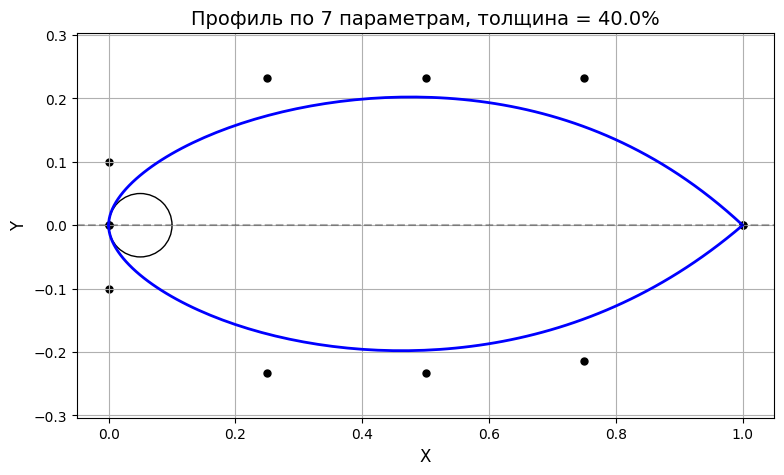

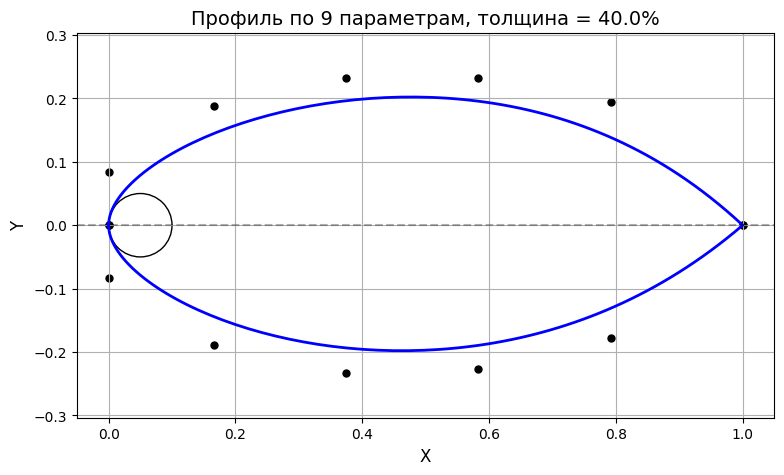

In [5]:
teta = np.deg2rad(75)
caca0012 = airfoil_structured(0.05, [0.2, 0.2, 0.2], [-0.2, -0.2], teta, 0, min_thick=40)
caca0012.plot(show_circle=True)
caca0012.elevate()
caca0012.plot(show_circle=True)

In [6]:
def selig_to_icem(in_file, out_file, n_points=500):
    try:
        data = np.loadtxt(in_file)
    except ValueError:
        data = np.loadtxt(in_file, skiprows=1)

    le_idx = np.argmin(data[:, 0])
    x_lin = np.linspace(0, 1, n_points)
    top_f = interp1d(data[:le_idx+1, 0][::-1], data[:le_idx+1, 1][::-1], kind='cubic')
    bot_f = interp1d(data[le_idx:, 0], data[le_idx:, 1], kind='cubic')
    with open(out_file, 'w') as f:
        f.write(f"{n_points} 2\n")
        np.savetxt(f, np.c_[x_lin, top_f(x_lin), np.zeros(n_points)], fmt='%.9f')
        np.savetxt(f, np.c_[x_lin, bot_f(x_lin), np.zeros(n_points)], fmt='%.9f')

In [7]:
def create_airfoil_from_params(params, points, teta, dy_te, min_thick):
    params = np.array(params)
    r_forw = params[0]/100
    up_coords = params[1:points+1]/10
    down_coords = params[points+1:]/10
    airfoil = airfoil_structured(r_forw, up_coords, down_coords, teta, dy_te, min_thick)
    return airfoil

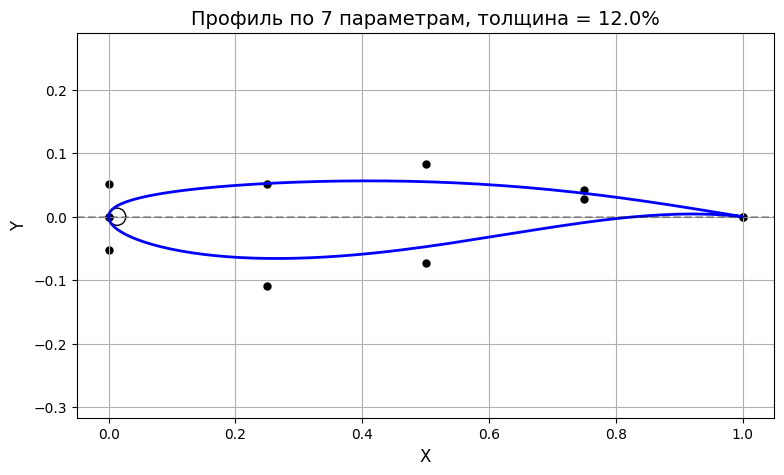

In [8]:
min_thick = 12  #минимальная толщина профиля в процентах от хорды
points = 3 #количество точек на верхней и нижней поверхностях профиля (без учета точек передней и задней кромок)
dy_te = 0.0 #зазор в задней кромке
teta = 2 #Угол задней кромки в  градусах
teta = np.deg2rad(teta)
params = [1.353e+00, 4.839e-01, 7.765e-01, 3.931e-01, -1.029e+00, -6.878e-01]
caca0012 = create_airfoil_from_params(params, points, teta, dy_te, min_thick)
caca0012.plot(show_circle=True)

In [9]:
def create_airfoil_from_norm_params(params, r_bound, point_bound, teta_bound, points, dy_te, min_thick):
    r_forw = params[0]*r_bound
    up_coords = params[1:points+1]*point_bound
    down_coords = params[points+1:-1]*point_bound
    teta = params[-1]*teta_bound
    airfoil = airfoil_structured(r_forw, up_coords, down_coords, teta, dy_te, min_thick)
    return airfoil

In [10]:
def airfoil_distance(airfoil, zero_airfoil):
    u1, d1 = airfoil.coords(100)
    u0, d0 = zero_airfoil.coords(100)
    dist = np.sum((np.array(u1) - np.array(u0))**2) + np.sum((np.array(d1) - np.array(d0))**2)
    return dist

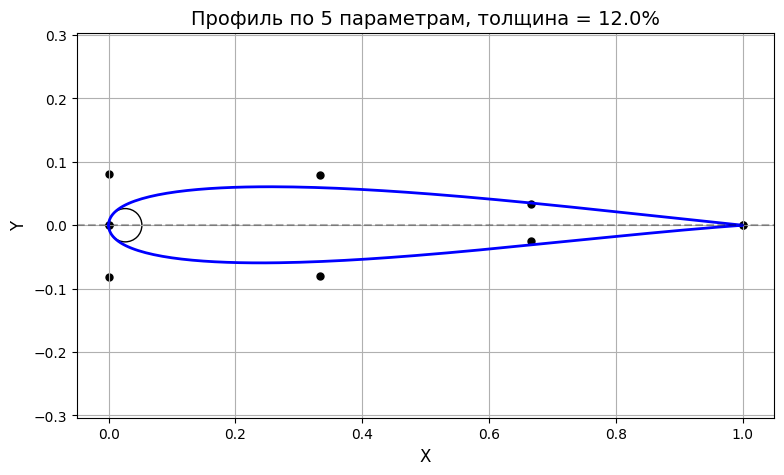

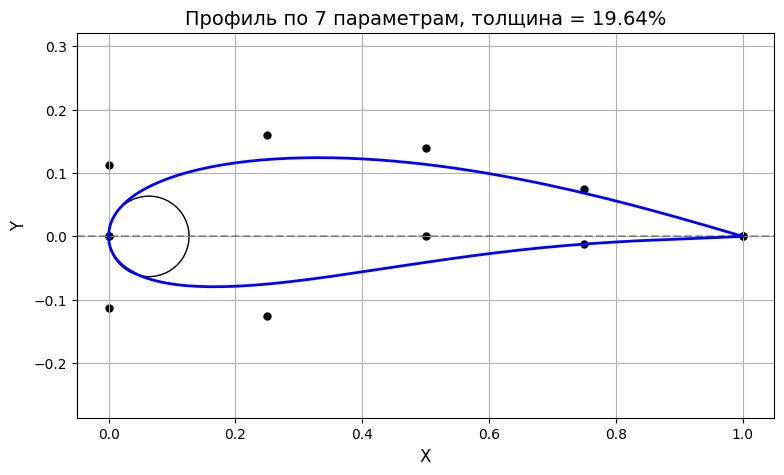

0.309334856262255


In [31]:
min_thick = 12  #минимальная толщина профиля в процентах от хорды
points = 3 #количество точек на верхней и нижней поверхностях профиля (без учета точек передней и задней кромок)
dy_te = 0.0 #зазор в задней кромке
teta_bound = 20 #Угол задней кромки в градусах
teta_bound = np.deg2rad(teta_bound)
r_bound = 0.07
point_bound = 0.2
dy_te = 0.00
sym_params = np.array([0.375, 0.17, -0.4, 0.5])
sym_airfoil = create_airfoil_from_norm_params_thick(sym_params, r_bound, point_bound, teta_bound, 2, dy_te, thick = 12, var_point = 1)
sym_airfoil.plot(show_circle=True)
params = np.array([ 0.9063,  0.8,  0.7,  0.3732,  -0.624, 0,  0.9718])
caca0012 = create_airfoil_from_norm_params(params, r_bound, point_bound, teta_bound, points, dy_te, min_thick=-1)
caca0012.plot(show_circle=True)
print(airfoil_distance(caca0012, sym_airfoil))

In [ ]:
def create_airfoil_from_norm_params_thick(params, r_bound, point_bound, teta_bound, points, dy_te, thick, var_point):
    succ = True
    def func(x):
        current_params = np.insert(params, var_point, x)
        airfoil = create_airfoil_from_norm_params(current_params, r_bound, point_bound, teta_bound, points, dy_te, min_thick=-1)
        return airfoil.thick()[0] - thick
    x0 = 1
    x = fsolve(func, x0)
    if x < -1 or x > 1:
        print(f"Невозможно достичь заданной толщины {thick}%. Решение вышло за пределы допустимых значений")
        succ = False
    current_params = np.insert(params, var_point, x)
    airfoil = create_airfoil_from_norm_params(current_params, r_bound, point_bound, teta_bound, points, dy_te, min_thick=-1)
    return succ, airfoil

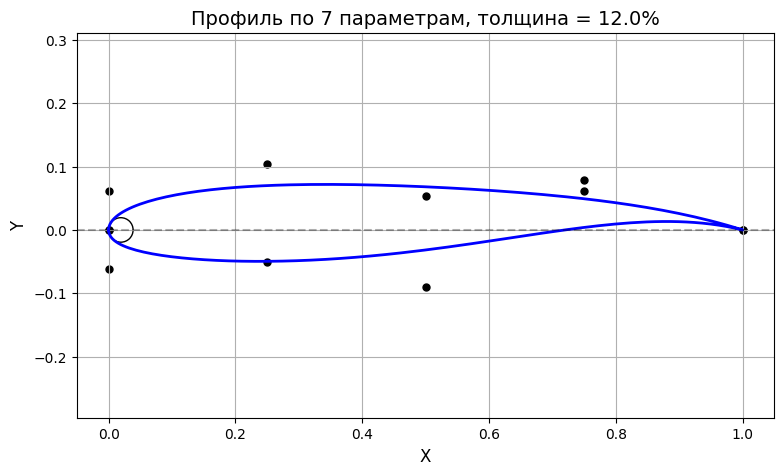

[ 0.27584822  0.52305892  0.26782427  0.39601285 -0.24895644 -0.44865642
  0.18463683]


In [51]:
min_thick = 12  #минимальная толщина профиля в процентах от хорды
points = 3 #количество точек на верхней и нижней поверхностях профиля (без учета точек передней и задней кромок)
dy_te = 0.0 #зазор в задней кромке
teta_bound = 20 #Угол задней кромки в градусах
teta_bound = np.deg2rad(teta_bound)
r_bound = 0.07
point_bound = 0.2
dy_te = 0.00
sym_params = np.array( [ 2.7584821968e-01,
 5.2305892018e-01,
 3.9601284883e-01,
-2.4895644401e-01,
-4.4865642324e-01,
 1.8463683338e-01])
caca0012 = create_airfoil_from_norm_params_thick(sym_params, r_bound, point_bound, teta_bound, points, dy_te, thick = 12, var_point = 2)
caca0012.plot(show_circle=True)
sym_elev_params = np.array([sym_params[0]] + list(caca0012.up_y_coords[2:-1]/point_bound) + list(caca0012.down_y_coords[2:-2]/point_bound) + [sym_params[-1]])
print(sym_elev_params)

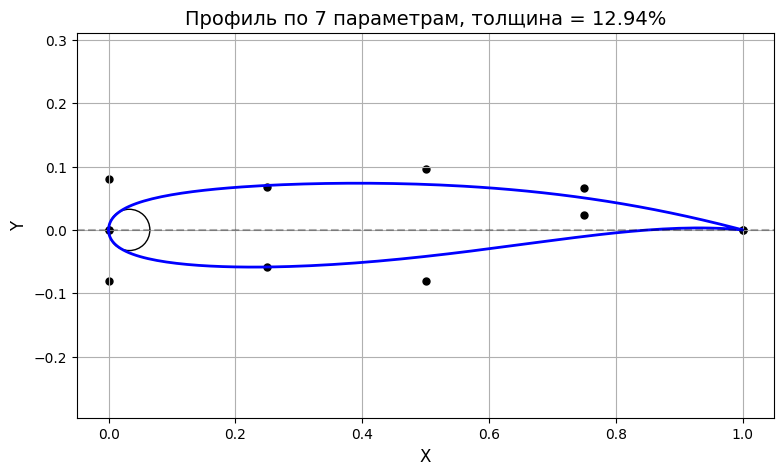

[ 0.46481481  0.33470508  0.47736626  0.32921811 -0.2962963  -0.40329218
  0.46296296]


In [32]:
min_thick = 12  #минимальная толщина профиля в процентах от хорды
points = 3 #количество точек на верхней и нижней поверхностях профиля (без учета точек передней и задней кромок)
dy_te = 0.0 #зазор в задней кромке
teta_bound = 20 #Угол задней кромки в градусах
teta_bound = np.deg2rad(teta_bound)
r_bound = 0.07
point_bound = 0.2
dy_te = 0.00
sym_params = np.array([ 0.46481481,  0.33470508,  0.47736626,  0.32921811, -0.2962963,  -0.40329218, 0.46296296])
caca0012 = create_airfoil_from_norm_params(sym_params, r_bound, point_bound, teta_bound, points, dy_te, min_thick=-1)
caca0012.create_icem_file(500)
caca0012.plot(show_circle=True)
sym_elev_params = np.array([sym_params[0]] + list(caca0012.up_y_coords[2:-1]/point_bound) + list(caca0012.down_y_coords[2:-2]/point_bound) + [sym_params[-1]])
print(sym_elev_params)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multiple_airfoils(airfoils, y_scale, labels, label):
    plt.figure(figsize=(13, 7))
    for i, airfoil in enumerate(airfoils):
        data = airfoil.coords(100)
        x_coords = np.append(data[0][0], data[1][0][::-1])
        y_coords = np.append(data[0][1], data[1][1][::-1]) 
        plt.plot(x_coords, y_coords, lw = 2, label=labels[i])
        
    plt.title(label, fontsize=16)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid()
    plt.margins(y=0.15)
    plt.gca().set_aspect(y_scale)
    
    plt.legend()

    plt.show()

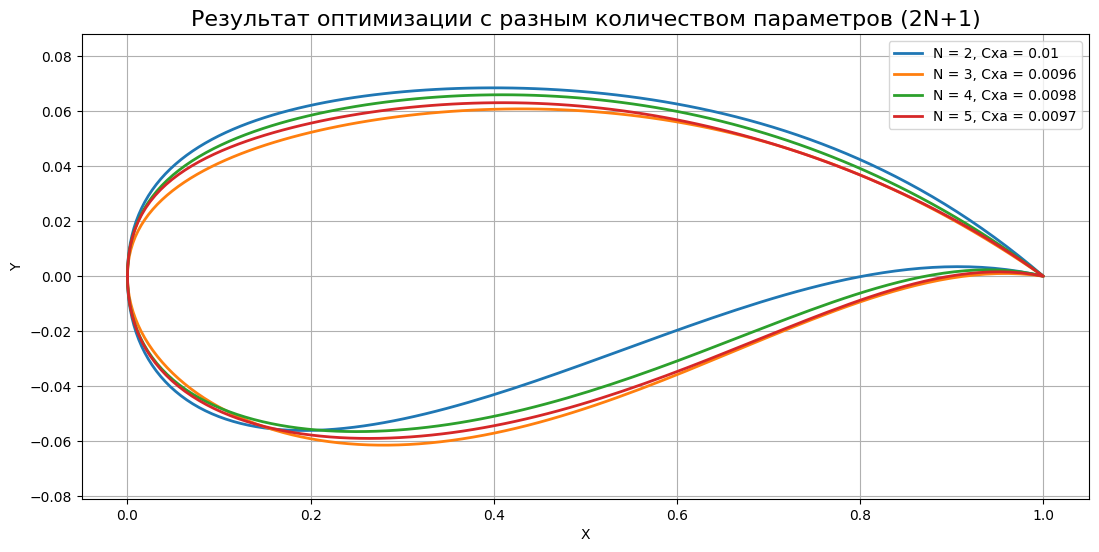

In [ ]:
z_airfoil = create_airfoil_from_norm_params(np.array([0.36736, 0.29982, 0.43995, -0.41946, 0.49543]), r_bound, point_bound, teta_bound, 2, dy_te, min_thick)
f_airfoil = create_airfoil_from_norm_params(np.array([ 0.1986,  0.278,   0.3714,  0.2704, -0.425,  -0.3536,  0.4602]), r_bound, point_bound, teta_bound, 3, dy_te, min_thick)
tw_airfoil = create_airfoil_from_norm_params(np.array([ 0.3142,  0.2928,  0.403,   0.3445,  0.2506, -0.3403, -0.3247, -0.2118,  0.4678]), r_bound, point_bound, teta_bound, 4, dy_te, min_thick)
th_airfoil = create_airfoil_from_norm_params(np.array([0.32037,  0.24516,  0.36316,  0.35839,  0.27411,  0.19895, -0.33251, -0.33933, -0.28244, -0.14256,  0.47018]), r_bound, point_bound, teta_bound, 5, dy_te, min_thick)
labels = ["N = 2, Cxa = 0.01", "N = 3, Cxa = 0.0096", "N = 4, Cxa = 0.0098", "N = 5, Cxa = 0.0097"]
label = "Результат оптимизации с разным количеством параметров (2N+1)"
plot_multiple_airfoils([z_airfoil, f_airfoil, tw_airfoil, th_airfoil], y_scale=3, labels=labels, label=label)

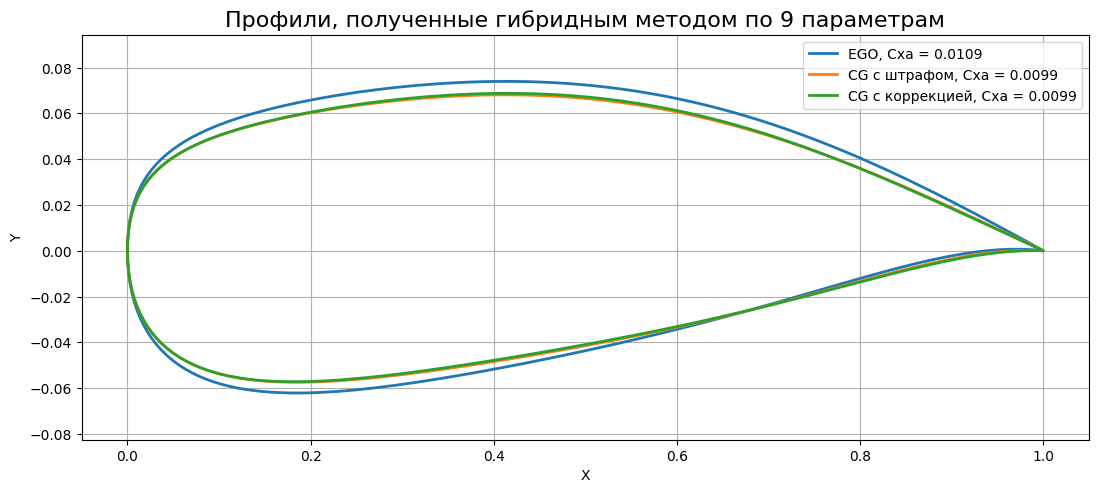

In [ ]:
f_airfoil = create_airfoil_from_norm_params(np.array([5.7222222222e-01, 2.4691358025e-01, 4.9382716049e-01, 4.1975308642e-01, 2.2222222222e-01, -4.4444444444e-01, -1.2345679012e-01, -3.4567901235e-01, 4.8765432099e-01]), r_bound, point_bound, teta_bound, 4, dy_te, min_thick)
tw_airfoil = create_airfoil_from_norm_params(np.array([ 0.5063,  0.1981,  0.4869,  0.3732,  0.1908, -0.4024, -0.1126, -0.3305,  0.4718]), r_bound, point_bound, teta_bound, 4, dy_te, min_thick)
th_airfoil = create_airfoil_from_norm_params(np.array([ 0.5063,  0.1961,  0.4829,  0.3838,  0.1803, -0.3999, -0.1033, -0.3202,  0.468 ]), r_bound, point_bound, teta_bound, 4, dy_te, min_thick)
labels = ["EGO, Cxa = 0.0109", "CG с штрафом, Cxa = 0.0099", "CG с коррекцией, Cxa = 0.0099"]
label = 'Профили, полученные гибридным методом по 9 параметрам'
plot_multiple_airfoils([f_airfoil, tw_airfoil, th_airfoil], y_scale=2.5, labels=labels, label=label)